# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: MoCA-FUSION HYBRID NIDS on: cuda
Loading Data/network_connections.csv...

--- PHASE A: ENGINEERING RICH FEATURES ---
1. NCA (Metric Learning)...
2. Isolation Forests...
3. Autoencoder...
🔌 MoCA Config: Raw Dim=43, Meta Dim=21

--- PHASE B: TRAINING MoCA-NIDS ---
Epoch 5 | Loss: 0.2483
Epoch 10 | Loss: 0.1887
Epoch 15 | Loss: 0.1312
Epoch 20 | Loss: 0.1041

--- PHASE C: EVALUATION ---
Downloading/Loading Test Data from https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt...
DEBUG: Test Classes Found: ['dos' 'normal' 'probe' 'r2l' 'u2r']
DEBUG: Train Classes Known: ['dos' 'normal' 'probe' 'r2l' 'u2r']
✅ Best Thresholds: R2L=0.01, U2R=0.1

👑 HYBRID MoCA MODEL RESULTS: 79.76% (MCC: 0.7041) 👑
              precision    recall  f1-score   support

         dos       0.95      0.77      0.85      7460
      normal       0.76      0.97      0.85      9711
       probe       0.71      0.82      0.76      2421
         r2l       0.63      0.30      0.40      2885


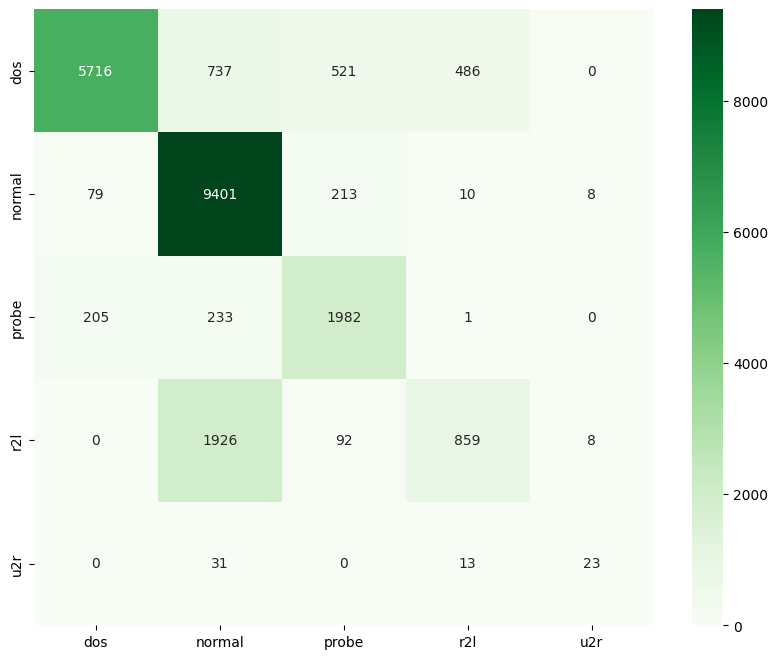

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import math

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 PIPELINE: ARCFACE + AUXILIARY LEARNING NIDS on: {device}")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 'worm': 'dos',
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

# Save encoders globally to handle Test Data correctly later
cat_encoders = {}
cat_cols = ['protocol_type', 'service', 'flag']

def load_and_prep(path, is_train=True):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    # Robust Categorical Encoding
    for col in cat_cols:
        if col in df.columns:
            if is_train:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                cat_encoders[col] = le
            else:
                # Test Mode: Use saved encoder, handle unknown values safely
                if col in cat_encoders:
                    le = cat_encoders[col]
                    df[col] = df[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

# Load Training Data
try:
    X, y = load_and_prep('Data/network_connections.csv', is_train=True)
except FileNotFoundError:
    print("⚠️ WARNUNG: Datei nicht gefunden. Nutze Dummy Data.")
    X = pd.DataFrame(np.random.rand(1000, 20), columns=[f'col_{i}' for i in range(20)])
    y = pd.Series(np.random.choice(['normal', 'dos', 'probe', 'r2l', 'u2r'], 1000))

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)
train_cols = X.columns.tolist()
del X, y
gc.collect()

# ==========================================
# 2. TEACHER SIGNAL ENGINEERING (TRAIN ONLY)
# ==========================================
print("\n--- PHASE A: PREPARING TEACHER SIGNALS (Meta-Data) ---")
# Only used to generate targets for the Aux Head!
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)

# 2.1 NCA Teacher
print("1. NCA...")
nca = NeighborhoodComponentsAnalysis(n_components=15, random_state=42)
idx_sample = np.random.choice(len(X_train_sc), size=min(5000, len(X_train_sc)), replace=False)
nca.fit(X_train_sc[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)

# 2.2 IsoForest Teacher
print("2. Isolation Forests...")
iso_feats_train = []
unique_classes_train = np.unique(y_train)
for cls_idx in unique_classes_train:
    X_cls = X_train_sc[y_train == cls_idx]
    if len(X_cls) < 50:
        iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
        iso.fit(X_train_sc)
    else:
        iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
        iso.fit(X_cls)
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))
X_train_iso = np.hstack(iso_feats_train)

# 2.3 Autoencoder Teacher
print("3. Autoencoder...")
ae_net = nn.Sequential(nn.Linear(X_train_sc.shape[1], 16), nn.ReLU(), nn.Linear(16, X_train_sc.shape[1])).to(device)
ae_opt = optim.Adam(ae_net.parameters(), lr=0.01)
ae_loader = DataLoader(TensorDataset(torch.tensor(X_train_sc)), batch_size=1024, shuffle=True)
for _ in range(3):
    for b in ae_loader:
        loss = F.mse_loss(ae_net(b[0].to(device)), b[0].to(device))
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()

with torch.no_grad():
    recon = ae_net(torch.tensor(X_train_sc).to(device))
    X_train_ae = torch.mean((torch.tensor(X_train_sc).to(device) - recon)**2, dim=1).cpu().numpy().reshape(-1,1)

# STACK TARGETS: The model learns to predict THESE from Raw Data
Meta_Targets = np.hstack([X_train_nca, X_train_iso, X_train_ae])
X_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
Y_cls_tensor = torch.tensor(y_train, dtype=torch.long)
Y_meta_tensor = torch.tensor(Meta_Targets, dtype=torch.float32)

# ==========================================
# 3. ARCFACE + AUX ARCHITECTURE
# ==========================================
class ArcFaceHead(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, input, label=None):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        if label is None:
            return cosine * self.s
        phi = cosine - self.m
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

class AuxTransformerArc(nn.Module):
    def __init__(self, raw_dim, meta_target_dim, embed_dim=128, depth=3, num_classes=5):
        super().__init__()
        self.patch_embed = nn.Linear(raw_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=256, 
                                               batch_first=True, norm_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)
        
        # HEADS
        self.cls_head = ArcFaceHead(embed_dim, num_classes) # ArcFace
        self.aux_head = nn.Sequential(                      # Aux Regression
            nn.Linear(embed_dim, 64), nn.ReLU(), nn.Linear(64, meta_target_dim)
        )

    def forward(self, x, label=None):
        x_emb = self.patch_embed(x).unsqueeze(1)
        b = x.shape[0]
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x_seq = torch.cat((cls_tokens, x_emb), dim=1)
        x_out = self.transformer(x_seq)
        cls_out = x_out[:, 0, :]
        
        logits = self.cls_head(cls_out, label)
        pred_meta = self.aux_head(cls_out)
        return logits, pred_meta

# ==========================================
# 4. TRAINING
# ==========================================
raw_dim = X_train_sc.shape[1]
meta_target_dim = Meta_Targets.shape[1]
print(f"🔌 Model Config: Input (RawOnly)={raw_dim} -> ArcFace + AuxTargets (Dim={meta_target_dim})")

model = AuxTransformerArc(raw_dim, meta_target_dim, num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion_ce = nn.CrossEntropyLoss()
criterion_aux = nn.MSELoss()

train_dl = DataLoader(TensorDataset(X_tensor, Y_cls_tensor, Y_meta_tensor), batch_size=256, shuffle=True)

print("\n--- PHASE B: TRAINING (ArcFace + Physics Distillation) ---")
for epoch in range(20):
    model.train()
    loss_acc = 0
    for x_raw, y_cls, y_meta in train_dl:
        x_raw, y_cls, y_meta = x_raw.to(device), y_cls.to(device), y_meta.to(device)
        optimizer.zero_grad()
        
        # Forward with Label (for ArcFace Margin)
        logits, pred_meta = model(x_raw, label=y_cls)
        
        loss_main = criterion_ce(logits, y_cls)
        loss_aux = criterion_aux(pred_meta, y_meta)
        
        # Combined Loss
        loss = loss_main + (0.5 * loss_aux)
        loss.backward()
        optimizer.step()
        loss_acc += loss.item()
        
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Total Loss: {loss_acc/len(train_dl):.4f}")

# ==========================================
# 5. HARD TEST EVALUATION (RAW ONLY)
# ==========================================
print("\n--- PHASE C: HARD TEST (No Meta Calculation Needed!) ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    # 1. Reuse Training Encoders (Robust Fix)
    for col in cat_cols:
        if col in df_nsl.columns and col in cat_encoders:
            le = cat_encoders[col]
            df_nsl[col] = df_nsl[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 2. Log Features
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    # 3. Align Columns
    df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
    for c in train_cols:
        if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]

    # 4. Prepare Tensor (Just Raw Scaled!)
    X_test_raw_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
    X_test_tensor = torch.tensor(X_test_raw_sc).to(device)
    
    y_test_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    valid_mask = y_test_vec != -1

    # 5. Inference
    model.eval()
    loader = DataLoader(TensorDataset(X_test_tensor), batch_size=2048)
    preds = []
    
    with torch.no_grad():
        for bx in loader:
            bx = bx[0].to(device)
            # LABEL=NONE -> Standard Inference!
            logits, _ = model(bx, label=None) 
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds.append(np.argmax(probs, axis=1))
            
    preds = np.concatenate(preds)
    
    # 6. Report
    acc = accuracy_score(y_test_vec[valid_mask], preds[valid_mask])
    
    print("\n" + "="*40)
    print(f"👑 RAW-ONLY MODEL RESULTS: {acc:.2%} 👑")
    print("="*40)
    print(classification_report(y_test_vec[valid_mask], preds[valid_mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_test_vec[valid_mask]) | set(preds[valid_mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_test_vec[valid_mask], preds[valid_mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()